In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanrao/nifty50-stock-market-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nifty50-stock-market-data' dataset.
Path to dataset files: /kaggle/input/nifty50-stock-market-data


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 5)

SYMBOL = "RELIANCE"


## 1. Load and inspect the data


In [ ]:
df = pd.read_csv(os.path.join(path, f"{SYMBOL}.csv"), parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date")
df.head()


,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,
2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


In [ ]:
df.tail()


,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,
2021-04-26,RELIANCE,EQ,1904.35,1920.00,1962.0,1911.50,1938.00,1937.85,1941.32,9620785,1.867699e+15,259137.0,4276703.0,0.4445
2021-04-27,RELIANCE,EQ,1937.85,1940.00,1997.2,1938.25,1990.00,1988.65,1978.64,9226547,1.825602e+15,291197.0,3772144.0,0.4088
2021-04-28,RELIANCE,EQ,1988.65,1997.85,2008.0,1980.15,1993.15,1997.30,1997.60,7902002,1.578508e+15,247331.0,3921560.0,0.4963
2021-04-29,RELIANCE,EQ,1997.30,2022.90,2044.5,2007.30,2020.00,2024.05,2024.21,8035915,1.626634e+15,213153.0,2834103.0,0.3527
2021-04-30,RELIANCE,EQ,2024.05,2008.50,2036.0,1987.55,1995.90,1994.50,2010.20,9150974,1.839532e+15,288687.0,3902504.0,0.4265


In [ ]:
print("Shape:", df.shape)
df.info()


Shape: (5306, 14)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5306 entries, 2000-01-03 to 2021-04-30
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Symbol              5306 non-null   object 
 1   Series              5306 non-null   object 
 2   Prev Close          5306 non-null   float64
 3   Open                5306 non-null   float64
 4   High                5306 non-null   float64
 5   Low                 5306 non-null   float64
 6   Last                5306 non-null   float64
 7   Close               5306 non-null   float64
 8   VWAP                5306 non-null   float64
 9   Volume              5306 non-null   int64  
 10  Turnover            5306 non-null   float64
 11  Trades              2456 non-null   float64
 12  Deliverable Volume  4792 non-null   float64
 13  %Deliverble         4792 non-null   float64
dtypes: float64(11), int64(1), object(2)
memory usage: 621.8+ KB


In [ ]:
df.describe()


,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5.306000e+03,5.306000e+03,2.456000e+03,4.792000e+03,4792.000000
mean,1010.984866,1012.602375,1026.823803,996.886977,1011.157143,1011.316839,1011.937409,5.583028e+06,6.076715e+14,1.452306e+05,2.280885e+06,0.435039
std,570.987079,572.575893,581.986757,560.703328,570.938608,571.046753,571.222520,4.983793e+06,8.369739e+14,1.297557e+05,1.882665e+06,0.144722
min,203.200000,205.500000,219.500000,197.150000,203.300000,203.200000,212.290000,5.282000e+04,4.295543e+12,2.991000e+03,2.909700e+04,0.076300
25%,572.137500,572.925000,582.950000,564.237500,572.062500,572.512500,573.190000,2.836454e+06,2.203354e+14,7.215900e+04,1.194524e+06,0.323325
50%,937.950000,939.000000,950.075000,927.550000,939.025000,938.275000,939.785000,4.213432e+06,3.662999e+14,1.021435e+05,1.810434e+06,0.449450
75%,1247.387500,1247.675000,1267.350000,1227.450000,1248.287500,1248.275000,1247.375000,6.602604e+06,6.656490e+14,1.686702e+05,2.752935e+06,0.544300
max,3220.850000,3298.000000,3298.000000,3141.300000,3223.000000,3220.850000,3197.750000,6.523089e+07,1.473434e+16,1.428490e+06,3.495888e+07,0.978300


In [ ]:
df.isna().sum()


,0
Symbol,0
Series,0
Prev Close,0
Open,0
High,0
Low,0
Last,0
Close,0
VWAP,0
Volume,0


In [ ]:
df.columns.tolist()


['Symbol',
 'Series',
 'Prev Close',
 'Open',
 'High',
 'Low',
 'Last',
 'Close',
 'VWAP',
 'Volume',
 'Turnover',
 'Trades',
 'Deliverable Volume',
 '%Deliverble']

In [ ]:
# Keep it to OHLCV + the last ~3 years for cleaner charts
ohlcv = df[["Open", "High", "Low", "Close", "Volume"]].dropna().tail(750)
ohlcv.head()


,Open,High,Low,Close,Volume
Date,,,,,
2018-04-19,939.10,945.00,935.00,942.30,4481413
2018-04-20,938.00,941.85,921.20,927.90,3349519
2018-04-23,930.00,944.35,928.50,936.00,3508515
2018-04-24,935.80,975.70,935.00,970.05,9107264
2018-04-25,973.65,981.80,963.55,970.50,6436620


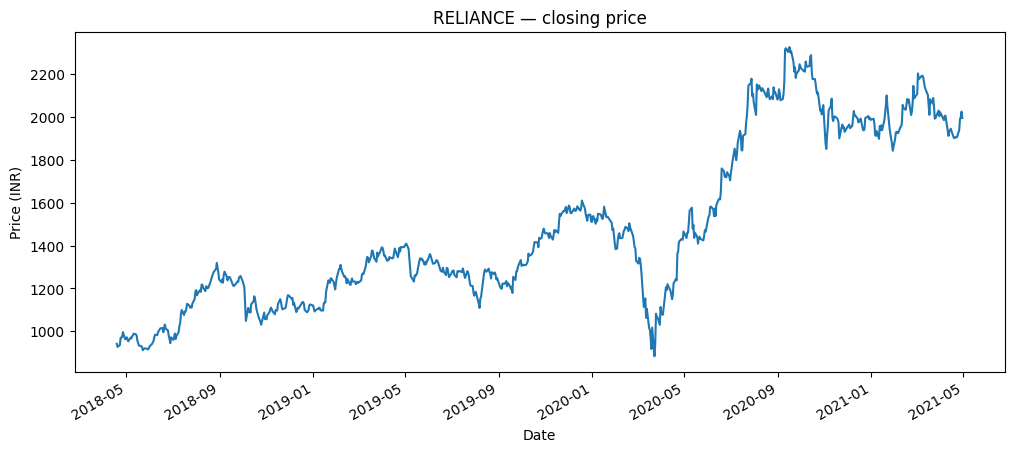

In [ ]:
ohlcv["Close"].plot(title=f"{SYMBOL} — closing price")
plt.ylabel("Price (INR)")
plt.show()


## 2. Moving averages (SMA / EMA)

Moving averages smooth out day-to-day noise to reveal the underlying trend. The classic combination used on most trading terminals (including NEST Trader) is a fast/medium/slow trio — here, 20/50/200-day SMAs — plus a "golden cross" / "death cross" signal where the 50 crosses the 200.


In [ ]:
def sma(series: pd.Series, window: int) -> pd.Series:
    return series.rolling(window=window, min_periods=window).mean()

def ema(series: pd.Series, window: int) -> pd.Series:
    return series.ewm(span=window, adjust=False).mean()

ohlcv["sma20"] = sma(ohlcv["Close"], 20)
ohlcv["sma50"] = sma(ohlcv["Close"], 50)
ohlcv["sma200"] = sma(ohlcv["Close"], 200)
ohlcv[["Close", "sma20", "sma50", "sma200"]].tail()


,Close,sma20,sma50,sma200
Date,,,,
2021-04-26,1937.85,1966.2800,2039.426,2048.16350
2021-04-27,1988.65,1963.3475,2040.076,2049.11675
2021-04-28,1997.30,1963.6400,2040.536,2049.98200
2021-04-29,2024.05,1965.1100,2039.903,2050.71200
2021-04-30,1994.50,1963.3700,2038.961,2051.00950


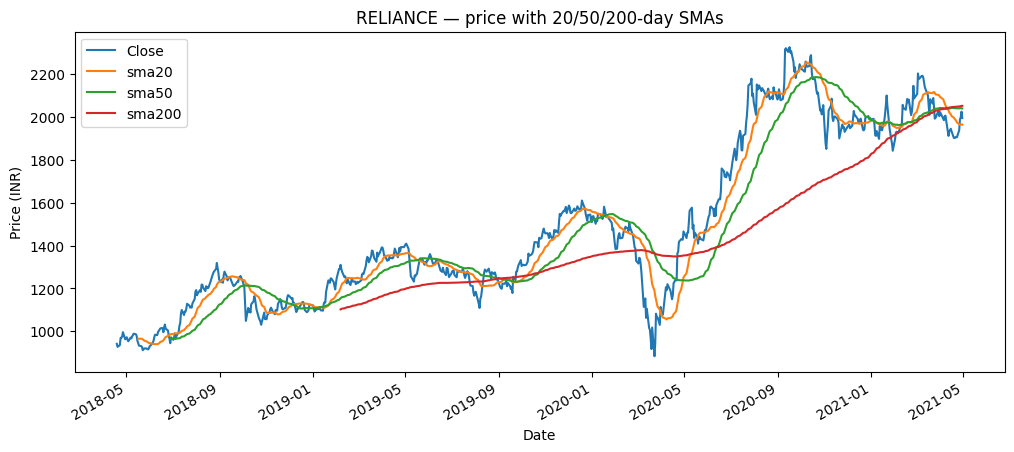

In [ ]:
ax = ohlcv[["Close", "sma20", "sma50", "sma200"]].plot(title=f"{SYMBOL} — price with 20/50/200-day SMAs")
ax.set_ylabel("Price (INR)")
plt.show()


In [ ]:
# Detect golden cross / death cross events (50-day crossing 200-day)
cross_up = (ohlcv["sma50"].shift(1) <= ohlcv["sma200"].shift(1)) & (ohlcv["sma50"] > ohlcv["sma200"])
cross_down = (ohlcv["sma50"].shift(1) >= ohlcv["sma200"].shift(1)) & (ohlcv["sma50"] < ohlcv["sma200"])

print("Golden crosses:", ohlcv.index[cross_up].tolist())
print("Death crosses :", ohlcv.index[cross_down].tolist())


Golden crosses: [Timestamp('2019-10-24 00:00:00'), Timestamp('2020-06-15 00:00:00')]
Death crosses : [Timestamp('2019-09-04 00:00:00'), Timestamp('2020-03-24 00:00:00'), Timestamp('2021-04-07 00:00:00')]


## 3. RSI (Relative Strength Index)

RSI measures momentum on a 0–100 scale. Conventionally, RSI ≥ 70 suggests overbought conditions and RSI ≤ 30 suggests oversold — exactly the kind of momentum read a NEST Trader-style terminal surfaces.


In [ ]:
def rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    out = 100 - (100 / (1 + rs))
    out = out.where(avg_loss != 0, np.where(avg_gain == 0, 50, 100))
    return pd.Series(out, index=series.index).fillna(50)

ohlcv["rsi14"] = rsi(ohlcv["Close"], 14)
ohlcv[["Close", "rsi14"]].tail()


,Close,rsi14
Date,,
2021-04-26,1937.85,42.908095
2021-04-27,1988.65,51.282480
2021-04-28,1997.30,52.558547
2021-04-29,2024.05,56.364961
2021-04-30,1994.50,51.453700


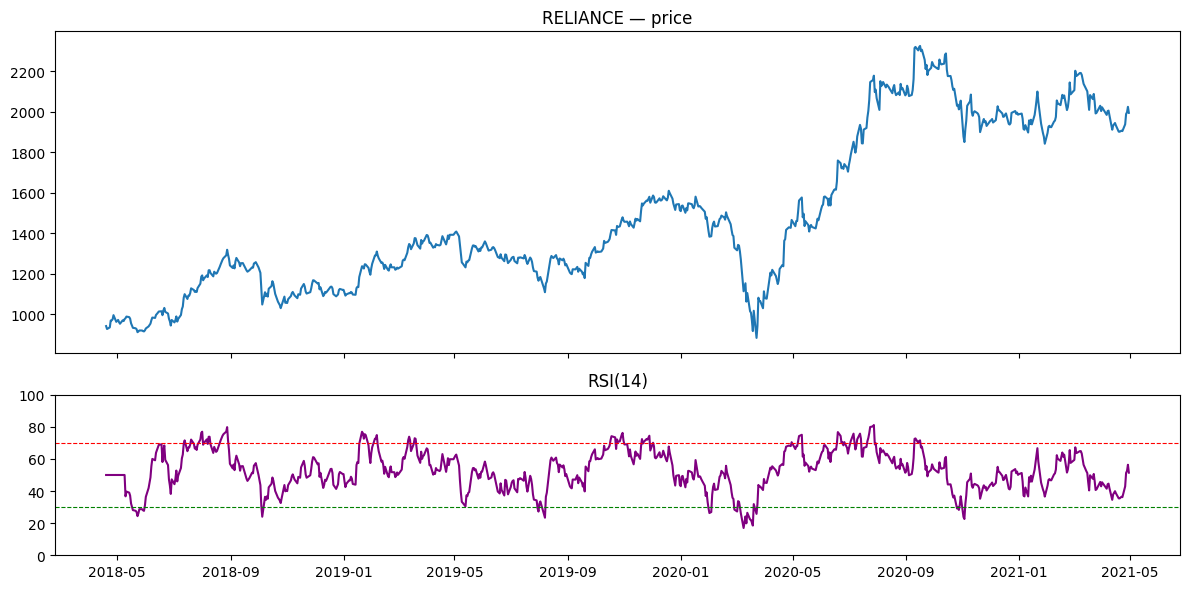

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 6), gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(ohlcv.index, ohlcv["Close"])
ax1.set_title(f"{SYMBOL} — price")

ax2.plot(ohlcv.index, ohlcv["rsi14"], color="purple")
ax2.axhline(70, color="red", linestyle="--", linewidth=0.8)
ax2.axhline(30, color="green", linestyle="--", linewidth=0.8)
ax2.set_title("RSI(14)")
ax2.set_ylim(0, 100)
plt.tight_layout()
plt.show()


In [ ]:
# Days currently flagged overbought / oversold
ohlcv[ohlcv["rsi14"] >= 70][["Close", "rsi14"]].tail()


,Close,rsi14
Date,,
2020-09-10,2314.00,72.445830
2020-09-11,2319.75,72.778361
2020-09-14,2302.55,70.054858
2020-09-15,2318.85,71.156444
2020-09-16,2324.55,71.550572


## 4. Support & resistance

A simple, explainable way to find support/resistance levels: scan for local extrema (a bar's High/Low that's the max/min within a window on both sides), then deduplicate levels that are too close together.


In [ ]:
def support_resistance(data: pd.DataFrame, window: int = 10, prominence: float = 0.015) -> dict:
    highs, lows = data["High"], data["Low"]
    n = len(data)
    resistance, support = [], []

    for i in range(window, n - window):
        local_high = highs.iloc[i - window: i + window + 1]
        local_low = lows.iloc[i - window: i + window + 1]
        if highs.iloc[i] == local_high.max():
            resistance.append(highs.iloc[i])
        if lows.iloc[i] == local_low.min():
            support.append(lows.iloc[i])

    def _dedup(levels):
        levels = sorted(levels)
        deduped = []
        for lvl in levels:
            if not deduped or abs(lvl - deduped[-1]) / deduped[-1] > prominence:
                deduped.append(lvl)
        return deduped

    return {"support": _dedup(support), "resistance": _dedup(resistance)}

levels = support_resistance(ohlcv.tail(250))
levels


{'support': [np.float64(1393.0),
  np.float64(1830.0),
  np.float64(1892.5),
  np.float64(2044.25),
  np.float64(2167.3)],
 'resistance': [np.float64(2038.0),
  np.float64(2095.0),
  np.float64(2198.8),
  np.float64(2231.9),
  np.float64(2309.0),
  np.float64(2369.35)]}

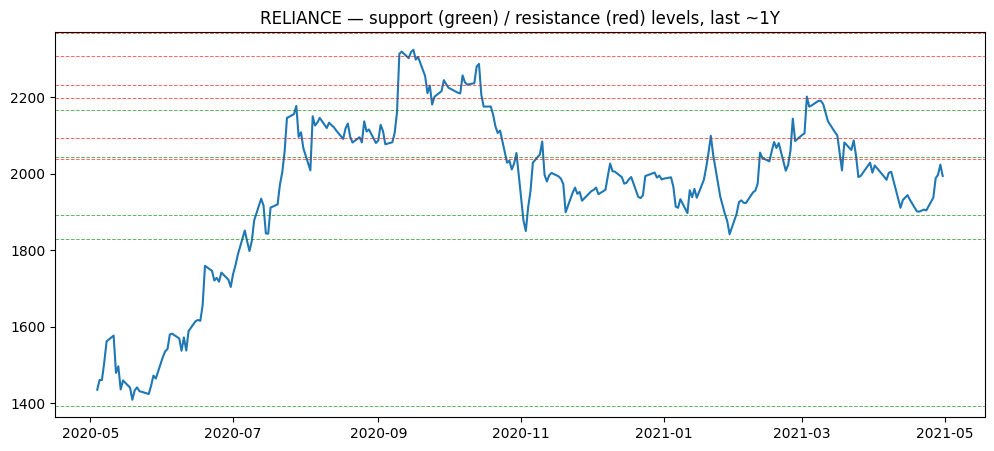

In [ ]:
fig, ax = plt.subplots()
ax.plot(ohlcv.tail(250).index, ohlcv.tail(250)["Close"], label="Close", zorder=1)
for lvl in levels["support"]:
    ax.axhline(lvl, color="green", linestyle="--", linewidth=0.7, alpha=0.6)
for lvl in levels["resistance"]:
    ax.axhline(lvl, color="red", linestyle="--", linewidth=0.7, alpha=0.6)
ax.set_title(f"{SYMBOL} — support (green) / resistance (red) levels, last ~1Y")
plt.show()


## 5. MACD and combined price-action signal tags

MACD (Moving Average Convergence Divergence) adds a second momentum confirmation layer. Combining it with the moving-average crosses and RSI thresholds above gives a single "signal" tag per day — similar to an alert feed on a trading terminal.


In [ ]:
def macd(series: pd.Series, fast=12, slow=26, signal=9):
    macd_line = ema(series, fast) - ema(series, slow)
    signal_line = ema(macd_line, signal)
    hist = macd_line - signal_line
    return macd_line, signal_line, hist

ohlcv["macd"], ohlcv["macd_signal"], ohlcv["macd_hist"] = macd(ohlcv["Close"])
ohlcv[["macd", "macd_signal", "macd_hist"]].tail()


,macd,macd_signal,macd_hist
Date,,,
2021-04-26,-38.425531,-35.136778,-3.288753
2021-04-27,-31.657594,-34.440941,2.783347
2021-04-28,-25.304281,-32.613609,7.309328
2021-04-29,-17.904342,-29.671756,11.767413
2021-04-30,-14.259897,-26.589384,12.329487


In [ ]:
def tag_signals(data: pd.DataFrame) -> pd.Series:
    tags = []
    for i in range(len(data)):
        row, prev = data.iloc[i], data.iloc[i - 1] if i > 0 else data.iloc[i]
        t = []
        if pd.notna(row["sma50"]) and pd.notna(row["sma200"]):
            if prev["sma50"] <= prev["sma200"] and row["sma50"] > row["sma200"]:
                t.append("golden_cross")
            elif prev["sma50"] >= prev["sma200"] and row["sma50"] < row["sma200"]:
                t.append("death_cross")
        if row["rsi14"] >= 70:
            t.append("overbought")
        elif row["rsi14"] <= 30:
            t.append("oversold")
        if pd.notna(row["macd_hist"]) and pd.notna(prev["macd_hist"]):
            if prev["macd_hist"] <= 0 and row["macd_hist"] > 0:
                t.append("macd_bull_cross")
            elif prev["macd_hist"] >= 0 and row["macd_hist"] < 0:
                t.append("macd_bear_cross")
        tags.append(",".join(t) if t else "neutral")
    return pd.Series(tags, index=data.index)

ohlcv["signal"] = tag_signals(ohlcv)
ohlcv[ohlcv["signal"] != "neutral"][["Close", "rsi14", "signal"]].tail(10)


,Close,rsi14,signal
Date,,,
2020-11-10,2084.55,50.907338,macd_bull_cross
2020-12-23,1943.85,42.572078,macd_bear_cross
2020-12-24,1994.15,52.147555,macd_bull_cross
2021-01-06,1914.25,37.129844,macd_bear_cross
2021-01-18,1983.95,53.328957,macd_bull_cross
2021-01-27,1895.00,40.997781,macd_bear_cross
2021-02-09,1956.15,50.976978,macd_bull_cross
2021-03-15,2108.90,52.346095,macd_bear_cross
2021-04-07,2002.85,44.217435,death_cross


In [ ]:
ohlcv["signal"].value_counts()


,count
signal,
neutral,587
overbought,64
oversold,34
macd_bear_cross,30
macd_bull_cross,26
"overbought,macd_bull_cross",4
death_cross,3
"golden_cross,overbought",1
golden_cross,1
